<a href="https://colab.research.google.com/github/bhavanamythrim/AI_TASKS/blob/main/AI_TASK_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

INPUT_SIZE = 1
NUM_CLASSES = 10
LEARNING_RATE = 0.001
BATCH_SIZE = 64
NUM_EPOCHS = 5

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super(CNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)

        x = x.reshape(x.size(0), -1)

        x = self.fc(x)
        return x

model = CNN(INPUT_SIZE, NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\nStarting Training...")
total_steps = len(train_loader)

train_losses = []
test_accuracies = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{total_steps}], Loss: {loss.item():.4f}')
    train_losses.append(epoch_loss / total_steps)

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Test Accuracy: {accuracy:.2f}%')

print(f'\nFinal Accuracy of the model on the 10000 test images: {test_accuracies[-1]:.2f}%')



Using device: cuda

Starting Training...
Epoch [1/5], Step [100/938], Loss: 0.1690
Epoch [1/5], Step [200/938], Loss: 0.0566
Epoch [1/5], Step [300/938], Loss: 0.1030
Epoch [1/5], Step [400/938], Loss: 0.0318
Epoch [1/5], Step [500/938], Loss: 0.0457
Epoch [1/5], Step [600/938], Loss: 0.0699
Epoch [1/5], Step [700/938], Loss: 0.0143
Epoch [1/5], Step [800/938], Loss: 0.0118
Epoch [1/5], Step [900/938], Loss: 0.1152
Epoch [1/5] Test Accuracy: 98.55%
Epoch [2/5], Step [100/938], Loss: 0.0907
Epoch [2/5], Step [200/938], Loss: 0.1685
Epoch [2/5], Step [300/938], Loss: 0.0172
Epoch [2/5], Step [400/938], Loss: 0.0361
Epoch [2/5], Step [500/938], Loss: 0.0136
Epoch [2/5], Step [600/938], Loss: 0.0299
Epoch [2/5], Step [700/938], Loss: 0.0176
Epoch [2/5], Step [800/938], Loss: 0.0147
Epoch [2/5], Step [900/938], Loss: 0.1304
Epoch [2/5] Test Accuracy: 98.58%
Epoch [3/5], Step [100/938], Loss: 0.0318
Epoch [3/5], Step [200/938], Loss: 0.0100
Epoch [3/5], Step [300/938], Loss: 0.0807
Epoch [3/

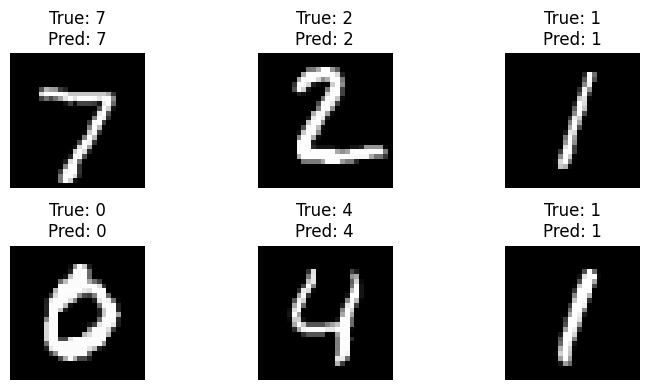

In [ ]:
model.eval()
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Move back to CPU for plotting
images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"True: {labels[i].item()}\nPred: {predicted[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

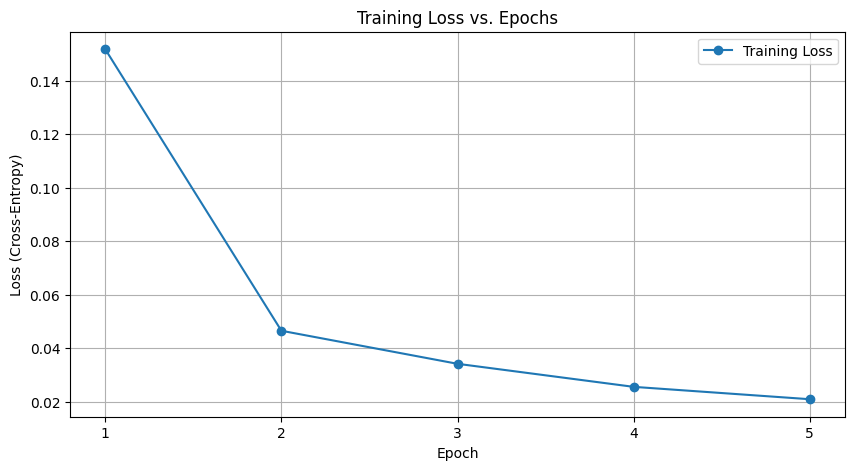

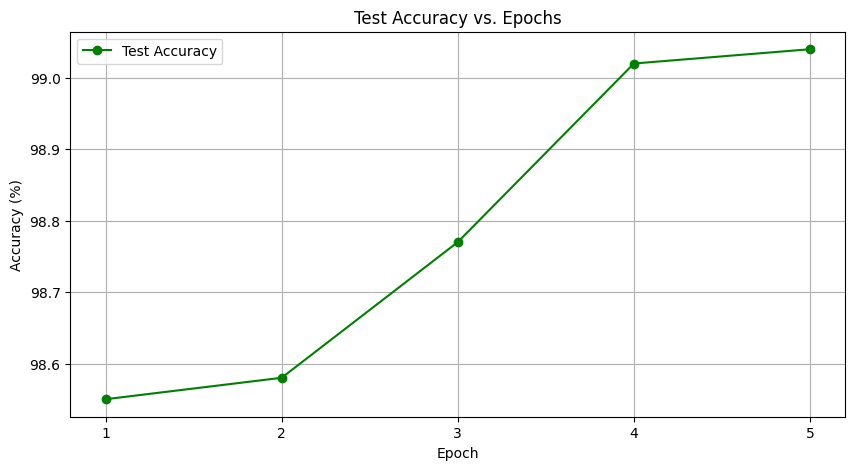

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', marker='o')
plt.title('Training Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, test_accuracies, label='Test Accuracy', color='green', marker='o')
plt.title('Test Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)
plt.show()